In [1]:
import numpy as np

# Function
def f(t, y):
    return y**2 - 10

# Derivative for Newton-Raphson
def fprime(y):
    return 2 * y

# Newton-Raphson for single step with Backward Euler
def backward_euler_step(f, y, t, h, tol=1e-6, max_iter=50):
    y_next = y  # Initial guess
    for _ in range(max_iter):
        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * fprime(y_next)
        
        if abs(g_prime_val) < tol:
            break
        
        y_new = y_next - g_val / g_prime_val
        
        if abs(y_new - y_next) < tol:
            return y_new
        
        y_next = y_new
        
    return y_next

# Adaptive Backward Euler
def backward_euler_adaptive(f, y0, t0, tf, h_init, tol=1e-6, max_iter=50):
    t_values = [t0]
    y_values = [y0]
    
    h = h_init
    t = t0
    y = y0

    while t < tf:
        if t + h > tf:
            h = tf - t

        # Full step
        y_full = backward_euler_step(f, y, t, h, tol, max_iter)

        # Two half steps
        h_half = h / 2
        y_half_1 = backward_euler_step(f, y, t, h_half, tol, max_iter)
        y_half_2 = backward_euler_step(f, y_half_1, t + h_half, h_half, tol, max_iter)

        # Error estimate
        error = abs(y_full - y_half_2)

        if error > tol:
            h /= 2
            continue
        elif error < tol / 2:
            h *= 2

        # Accept step
        t += h
        y = y_half_2

        t_values.append(t)
        y_values.append(y)

    return np.array(t_values), np.array(y_values)

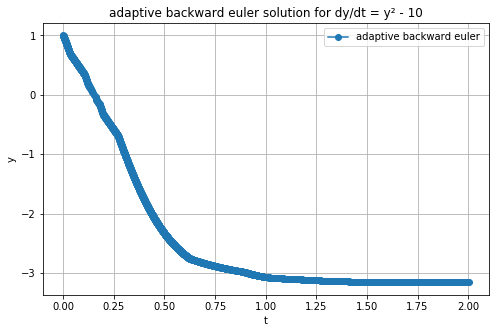

In [5]:
import matplotlib.pyplot as plt

# Initial conditions
y0 = 1
t0 = 0
tf = 2
h_init = 0.1

t_values, y_values = backward_euler_adaptive(f, y0, t0, tf, h_init)

plt.figure(figsize=(8, 5))
plt.plot(t_values, y_values, marker='o', label="adaptive backward euler")
plt.xlabel("t")
plt.ylabel("y")
plt.title("adaptive backward euler solution for dy/dt = y² - 10")
plt.grid(True)
plt.legend()
plt.show()

OpenAI. ChatGPT (GPT-5.3). 2026. ChatGPT was prompted to help with plotting and understand flow of the code. 

In [ ]:
e